# Optimal Model

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random

from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold, TimeSeriesSplit
from mlxtend.evaluate import GroupTimeSeriesSplit
from mlxtend.evaluate.time_series import plot_splits
from sklearn.metrics import mean_squared_error, r2_score

import keras

import tensorflow as tf
from tensorflow.keras.layers import MaxPooling1D
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau
import datetime

%load_ext tensorboard


2025-10-01 18:01:12.257390: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-01 18:01:12.257550: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-01 18:01:12.259232: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-01 18:01:12.277545: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-01 18:01:12.695002: W tensorflow/compiler/tf2tensorrt/uti

In [2]:
def set_reproducible(seed=12345):
    np.random.seed(seed)
    random.seed(seed)
    tf.random.set_seed(seed)

In [3]:
dps1200 = pd.read_csv("dps1200.csv")

In [4]:
dps1200 = dps1200[dps1200["year"] >= 1800]

In [5]:
print(type(dps1200))

<class 'pandas.core.frame.DataFrame'>


In [5]:
features = dps1200.iloc[:, 4:].values
labels = dps1200.iloc[:, 0].values

In [ ]:
#labels = tf.cast(labels, tf.int64)

In [6]:
print(len(labels))

575


First redifine the model into a function where the hyperparameters are inputs. This function evaluates the model and ouptups a desired score/metric.

In [11]:
def build_model(DenseN, DropoutR, C1_K, C1_S, C2_K, C2_S, C3_K, C3_S, input_dim):

    activation1='relu'
    activation2='linear'
    
    model = keras.Sequential()
    model.add(keras.layers.Input((input_dim, 1)))
    model.add(keras.layers.GaussianNoise(0.0001))

    model.add(keras.layers.Conv1D(C1_K, (C1_S), padding='valid', activation=activation1))
    model.add(keras.layers.Conv1D(C2_K, (C2_S), padding='valid', activation=activation1))
    model.add(keras.layers.Conv1D(C3_K, (C3_S), padding='valid', activation=activation1))
    model.add(MaxPooling1D(pool_size=2))

    model.add(keras.layers.Flatten())
    model.add(keras.layers.Dropout(DropoutR))
    
    model.add(keras.layers.Dense(DenseN, activation=activation1))
    model.add(keras.layers.Dense(DenseN, activation=activation1))
    model.add(keras.layers.Dense(DenseN, activation=activation1))
    model.add(keras.layers.Dense(1, activation=activation2))

    model.compile(loss=tf.keras.losses.Huber(), optimizer=keras.optimizers.Adam(learning_rate=0.001), metrics=['mean_absolute_error'])
    
    return model


In [12]:
model_cnn = build_model(DenseN=351, DropoutR=0.0, C1_K=55, C1_S=45, C2_K=43, C2_S=36, C3_K=63, C3_S=1, input_dim = 410)

In [13]:
x = np.array(features)
y = np.array(labels)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print(x_train)


[[ 0.01808268  0.01831599  0.01855557 ... -0.01763911 -0.01766709
  -0.01771786]
 [ 0.01988382  0.02044213  0.02101224 ... -0.01882859 -0.01885852
  -0.01891452]
 [ 0.01969391  0.0200056   0.02033284 ... -0.02378143 -0.02383113
  -0.02390226]
 ...
 [ 0.02047561  0.02068097  0.02088021 ... -0.01883355 -0.01889119
  -0.01896556]
 [ 0.01496814  0.0154088   0.01587775 ... -0.01864228 -0.01865161
  -0.01869576]
 [ 0.02267985  0.02335259  0.02403996 ... -0.02158631 -0.02162659
  -0.02168098]]


In [ ]:
cnn = model_cnn.fit(x, y, epochs=200, batch_size=45, validation_split=0.2)a


Epoch 1/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 1910.6538 - mean_absolute_error: 1912.3508 - val_loss: 1698.0912 - val_mean_absolute_error: 1699.7646
Epoch 2/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 1206.4025 - mean_absolute_error: 1215.7522 - val_loss: 276.1281 - val_mean_absolute_error: 277.3876
Epoch 3/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 238.9860 - mean_absolute_error: 240.0204 - val_loss: 131.9105 - val_mean_absolute_error: 132.8048
Epoch 4/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 116.7621 - mean_absolute_error: 117.5675 - val_loss: 95.7506 - val_mean_absolute_error: 96.9264
Epoch 5/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 84.4225 - mean_absolute_error: 85.1900 - val_loss: 54.4416 - val_mean_absolute_error: 56.9696
Epoch 6/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 59.9856 - mean_absolute_error: 60.3600 - val_loss: 51.5851 - val_mean_absolute_error: 53.8207
Epoch 7/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - lo

# Crossvalidation

Since NN training involves random sampling and weights initialization (in this case), it is usefull to use cross-validation.

In [61]:
## Compute error metrics
def error_metrices(y_true_train, y_predicted_train, y_true_test, y_predicted_test):
    rmse_train = np.sqrt(mean_squared_error(y_true_train, y_predicted_train))
    rmse_test = np.sqrt(mean_squared_error(y_true_test, y_predicted_test))
    R2_train= r2_score(y_true_train, y_predicted_train)
    R2_test= r2_score(y_true_test, y_predicted_test)
    h = tf.keras.losses.Huber()
    hub_train = h(y_true_train, y_predicted_train).numpy()
    hub_test = h(y_true_test, y_predicted_test).numpy()
    
    print('*********** Benchmark results ***********\n')
    print(f"R2    (Train/Test) = {R2_train:.3f} / {R2_test:.3f}")
    print(f"RMSE  (Train/Test) = {rmse_train:.3f} / {rmse_test:.3f}")
    print(f"Huber (Train/Test) = {hub_train:.3f} / {hub_test:.3f}")

    return (rmse_train, rmse_test, R2_train, R2_test, hub_train, hub_test)

class ModelWithData:
    def __init__(self, history, train_x, train_label, train_predicted, test_x, test_label, test_predicted, score:float, iteration, model) -> None:
        self.history = history
        self.train_x = train_x
        self.train_label = train_label
        self.train_predicted = train_predicted
        self.test_x = test_x
        self.test_label = test_label
        self.test_predicted = test_predicted
        self.score = score
        self.iteration = iteration
        self.model = model

    def isBetter(self, otherScore: float) -> bool:
        return otherScore < 0 or (self.score >= 0 and self.score <= otherScore)

In [64]:

def evaluations_of_models(features, labels, DenseN, DropoutR, C1_K, C1_S, C2_K, C2_S, C3_K, C3_S, seed=12345, name="Anabell", epochs=100, n_splits=2):    

    x = np.array(features)
    y = np.array(labels)
    #groups = calculate_groups(y, years_in_group)
    input_dim = 410
    
    # generate model
    model = build_model(DenseN, DropoutR, C1_K, C1_S, C2_K, C2_S, C3_K, C3_S, input_dim)

    scores_train = { "rmse": [], "r2": [], "huber": []}
    scores_test = { "rmse": [], "r2": [], "huber": []}


    #monitor = EarlyStopping(monitor='val_loss', min_delta=4e-5, patience=50, verbose=0, mode='auto', restore_best_weights=True)
    #rdlr = ReduceLROnPlateau(patience=25, factor=0.5, min_lr=1e-6, monitor='val_loss', verbose=1)

    bestMwd = ModelWithData(None, 0, 0, 0, 0, 0, 0, -1, 0, None)

    tensorboard_base_dir = "tensorboard_logs"
    time_string = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
    
    i = 0
    set_reproducible(seed)
    i = i + 1
    print(f'\n\n> Fold {i}')

    tensorboard_log_dir = f"{tensorboard_base_dir}/{name}/{time_string}/{seed}/fold_{i}"
    tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=tensorboard_log_dir)

    x_train, x_test, y_train, y_test = train_test_split(features, labels, test_size=0.2, random_state=42)

    x_train, x_test = x[x_train], x[x_test]
    y_train, y_test = y[y_train], y[y_test]

    # Training the CNN-Model on X_train_fold, y_train_fold

    history = model.fit(x_train, y_train,
                        epochs=epochs, batch_size=45,
                        validation_data=(x_test, y_test),
                        verbose=0,
                        callbacks=[tensorboard_callback])

    # Evaluation of the model on X_test_fold, y_test_fold
    evaluation_results = model.evaluate(x_test, y_test, verbose=0)
    evaluation_labels = model.metrics_names

    for j in range(len(evaluation_results)):
        print(f'{evaluation_labels[j]}: {evaluation_results[j]}')

    # Analyse error metrics

    train_pred = model.predict(x_train, verbose=0)
    test_pred = model.predict(x_test, verbose=0)

    (rmse_train, rmse_test, r2_train, r2_test, huber_train, huber_test) = error_metrices(y_train, train_pred, y_test, test_pred)

    mwd = ModelWithData(history, x_train, y_train, train_pred, x_test, y_test, test_pred, rmse_test, i, model)

    if mwd.isBetter(bestMwd.score):
        bestMwd = mwd

    scores_train["rmse"].append(rmse_train)
    scores_train["r2"].append(r2_train)
    scores_train["huber"].append(huber_train)

    scores_test["rmse"].append(rmse_test)
    scores_test["r2"].append(r2_test)
    scores_test["huber"].append(huber_test)

    ## clear session 
    tf.keras.backend.clear_session()

    scores_train_mean = {}
    scores_test_mean = {}
    num_model = len(scores_train["rmse"])

    for metric in scores_train.keys():
        scores_train_mean[metric] = np.mean(scores_train[metric])
        scores_test_mean[metric] = np.mean(scores_test[metric])
        print(f'Train: {metric} (mean of {num_model} models)= {scores_train_mean[metric]} \nTest: {metric} (mean of {num_model} models)= {scores_test_mean[metric]}')

    return bestMwd

In [67]:
bestMwd = evaluations_of_models(features, labels, DenseN=351, DropoutR=0.0, C1_K=55, C1_S=45, C2_K=43, C2_S=36, C3_K=63, C3_S=1, seed=12345, name="Julia", epochs=100, n_splits=2)
print(f"Best model is from iteration {bestMwd.iteration}")



> Fold 1


TypeError: Only integers, slices (`:`), ellipsis (`...`), tf.newaxis (`None`) and scalar tf.int32/tf.int64 tensors are valid indices, got array([ 68, 231,  63, 436,  60,  15, 131, 478, 473, 208,  88, 545, 117,
       352, 375,  33,   0, 568, 140, 318, 434,  22, 407, 250,  89, 465,
       355,  18, 176, 500, 144, 518, 247, 218, 196, 512, 368,  54, 331,
        46,  93, 235, 108, 249, 574, 445, 403, 195, 350, 188, 364, 422,
       437,  69, 483, 257, 371, 548, 354, 149, 124, 432, 322, 369, 564,
       348, 410, 336, 529, 421, 114, 141, 311,   7, 487,  19, 172, 547,
        56, 277, 309, 463, 296, 284,  49, 238,  25, 497, 319, 272,  42,
       393, 396, 425, 446, 431, 154, 126, 405, 316, 412, 174,  31, 113,
       244, 173, 289, 367,  57, 505, 222,  24,  17, 274,  66, 338, 509,
       321, 507, 190, 457, 353, 494, 248,  94, 180, 312, 429,  92,  23,
       304, 301, 399, 400,   5, 116,  45, 220, 513, 357, 349,  16,  48,
       554, 452,   3, 299, 332, 225,  26, 263,  50, 229,  37, 157, 237

In [31]:
y = np.array(labels)

all(y[i] <= y[i+1] for i in range(len(y) - 1))

True

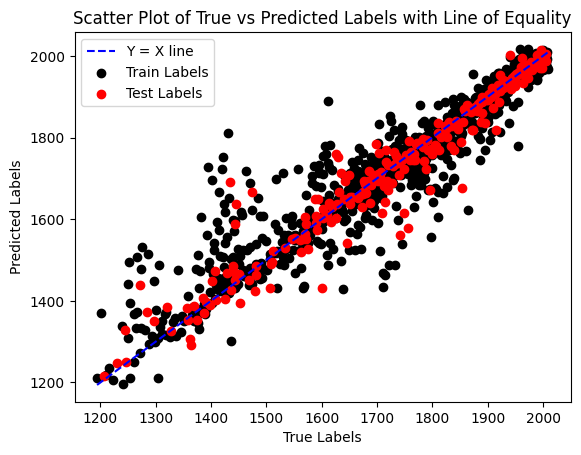

In [13]:
# Create an array of x-values ranging from the minimum to maximum of the data
x_values = np.linspace(min(labels), max(labels), 100)

# Plot the line of equality (y=x)
plt.plot(x_values, x_values, color='blue', linestyle='--', label='Y = X line')

# Scatter plot for predicted values
plt.scatter(bestMwd.train_label, bestMwd.train_predicted, c='k', label='Train Labels')
plt.scatter(bestMwd.test_label, bestMwd.test_predicted, c='r', label='Test Labels')

# Labels, legend, and title
plt.xlabel('True Labels')
plt.ylabel('Predicted Labels')
plt.legend()
plt.title('Scatter Plot of True vs Predicted Labels with Line of Equality')

# Show the plot
plt.show()

## Save the model

In [14]:
bestMwd.model.save('dps1200sub_model.keras')

# Check if working

In [15]:
dps1200sub_model = tf.keras.models.load_model('dps1200sub_model.keras')

# Show the model architecture
dps1200sub_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gaussian_noise (GaussianNoise)  │ (None, 410, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 366, 55)        │         2,530 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 331, 43)        │        85,183 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 331, 63)        │         2,772 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 165, 63)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10395)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10395)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 351)            │     3,648,996 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 351)            │       123,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 351)            │       123,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           352 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,960,813 (45.63 MB)

 Trainable params: 3,986,937 (15.21 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 7,973,876 (30.42 MB)

# Evaluation of the restored model

In [16]:
evaluation_results = dps1200sub_model.evaluate(features, labels, verbose=0)
evaluation_labels = dps1200sub_model.metrics_names

for j in range(len(evaluation_results)):
    print(f'{evaluation_labels[j]}: {evaluation_results[j]}')


loss: 34.45152282714844
compile_metrics: 35.38374328613281


In [17]:
def error_metrices_restored_model(y_true, y_predicted):
    rmse_train = np.sqrt(mean_squared_error(y_true, y_predicted))
    R2_train= r2_score(y_true, y_predicted)
    h = tf.keras.losses.Huber()
    hub_train = h(y_true, y_predicted).numpy()
    
    print('*********** Benchmark results ***********\n')
    print(f"R2    = {R2_train:.3f}")
    print(f"RMSE  = {rmse_train:.3f}")
    print(f"Huber = {hub_train:.3f}")

In [18]:
restored_pred = dps1200sub_model.predict(features, verbose=0)

In [19]:
error_metrices_restored_model(labels, restored_pred)

*********** Benchmark results ***********

R2    = 0.902
RMSE  = 61.404
Huber = 34.892
